In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ipaddress
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 200)


DATA_DIR = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\raw\cicids_v3")
DUCKDB_PATH = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\interim\cicids_eda.duckdb")
DUCKDB_PATH.parent.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DUCKDB_PATH))

# Get all distinct IPs (source + destination) with attack context
print("Extracting distinct IPs (this may take 30-60 seconds)...")

src_ips = con.execute("""
    SELECT 
        "Source IP" AS ip,
        'source' AS direction,
        COUNT(*) AS event_count,
        SUM(CASE WHEN is_attack = 1 THEN 1 ELSE 0 END) AS attack_count,
        COUNT(DISTINCT attack_family) AS unique_attack_families
    FROM stg_cicids_final
    WHERE "Source IP" IS NOT NULL
    GROUP BY "Source IP"
""").fetchdf()

dest_ips = con.execute("""
    SELECT 
        "Destination IP" AS ip,
        'destination' AS direction,
        COUNT(*) AS event_count,
        SUM(CASE WHEN is_attack = 1 THEN 1 ELSE 0 END) AS attack_count,
        COUNT(DISTINCT attack_family) AS unique_attack_families
    FROM stg_cicids_final
    WHERE "Destination IP" IS NOT NULL
    GROUP BY "Destination IP"
""").fetchdf()

print(f"Distinct source IPs: {len(src_ips):,}")
print(f"Distinct destination IPs: {len(dest_ips):,}")

# Classify each IP
def classify_ip(ip_str):
    try:
        ip = ipaddress.ip_address(ip_str)
        if ip.is_private:
            return 'internal'
        elif ip.is_loopback or ip.is_link_local or ip.is_multicast or ip.is_reserved:
            return 'special'
        else:
            return 'external'
    except (ValueError, TypeError):
        return 'invalid'

src_ips['ip_class'] = src_ips['ip'].apply(classify_ip)
dest_ips['ip_class'] = dest_ips['ip'].apply(classify_ip)

print("\n=== Source IP classification ===")
print(src_ips.groupby('ip_class').agg(
    unique_ips=('ip', 'count'),
    total_events=('event_count', 'sum'),
    total_attacks=('attack_count', 'sum')
))

print("\n=== Destination IP classification ===")
print(dest_ips.groupby('ip_class').agg(
    unique_ips=('ip', 'count'),
    total_events=('event_count', 'sum'),
    total_attacks=('attack_count', 'sum')
))


Extracting distinct IPs (this may take 30-60 seconds)...
Distinct source IPs: 17,005
Distinct destination IPs: 19,112

=== Source IP classification ===
          unique_ips  total_events  total_attacks
ip_class                                         
external       16988        363568          705.0
internal          17       2467175       556941.0

=== Destination IP classification ===
          unique_ips  total_events  total_attacks
ip_class                                         
external       19020        764582         1297.0
internal          87       2064823       556349.0
special            5          1338            0.0


In [2]:
# External source IPs with attack involvement — these are your geo-mapping prospects
external_attackers = src_ips[
    (src_ips['ip_class'] == 'external') & 
    (src_ips['attack_count'] > 0)
].sort_values('attack_count', ascending=False)

print(f"=== External attacker IPs (geo-mapping candidates) ===")
print(f"Total: {len(external_attackers)}\n")
print(external_attackers.head(20).to_string(index=False))

# Save the master list of IPs needing geo enrichment
all_external_ips = pd.concat([
    src_ips[src_ips['ip_class'] == 'external']['ip'],
    dest_ips[dest_ips['ip_class'] == 'external']['ip']
]).drop_duplicates().reset_index(drop=True)

print(f"\nTotal unique external IPs to enrich with MaxMind: {len(all_external_ips):,}")

=== External attacker IPs (geo-mapping candidates) ===
Total: 1

            ip direction  event_count  attack_count  unique_attack_families ip_class
205.174.165.73    source          712         705.0                       2 external

Total unique external IPs to enrich with MaxMind: 19,035


In [3]:
from pathlib import Path

interim_dir = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\interim")
interim_dir.mkdir(parents=True, exist_ok=True)

# Save full list of external IPs for MaxMind enrichment in Week 3
all_external_ips.to_frame('ip_address').to_csv(
    interim_dir / "external_ips_to_geocode.csv",
    index=False
)
print(f"✅ Saved {len(all_external_ips):,} external IPs to: external_ips_to_geocode.csv")

# Save the attacker IP profile (with attack context) for richer dashboard
external_attackers.to_csv(
    interim_dir / "external_attackers_profile.csv",
    index=False
)
print(f"✅ Saved attacker profile with {len(external_attackers):,} IPs to: external_attackers_profile.csv")

✅ Saved 19,035 external IPs to: external_ips_to_geocode.csv
✅ Saved attacker profile with 1 IPs to: external_attackers_profile.csv


In [4]:
# Detailed internal IP breakdown
print("=== Top internal source IPs (attack origins) ===")
print(con.execute("""
    SELECT 
        "Source IP",
        COUNT(*) AS total_events,
        SUM(CASE WHEN is_attack = 1 THEN 1 ELSE 0 END) AS attack_count,
        STRING_AGG(DISTINCT attack_family, ', ') 
            FILTER (WHERE attack_family NOT IN ('Benign', 'Unlabeled')) AS attack_families
    FROM stg_cicids_final
    WHERE "Source IP" IS NOT NULL
      AND "Source IP" LIKE '192.168.%'
    GROUP BY "Source IP"
    ORDER BY attack_count DESC
""").fetchdf().to_string())

print("\n=== Top internal destination IPs (attack targets) ===")
print(con.execute("""
    SELECT 
        "Destination IP",
        COUNT(*) AS total_events,
        SUM(CASE WHEN is_attack = 1 THEN 1 ELSE 0 END) AS attack_count,
        STRING_AGG(DISTINCT attack_family, ', ') 
            FILTER (WHERE attack_family NOT IN ('Benign', 'Unlabeled')) AS attack_families
    FROM stg_cicids_final
    WHERE "Destination IP" IS NOT NULL
      AND "Destination IP" LIKE '192.168.%'
    GROUP BY "Destination IP"
    ORDER BY attack_count DESC
    LIMIT 20
""").fetchdf().to_string())

=== Top internal source IPs (attack origins) ===
        Source IP  total_events  attack_count       attack_families
0   192.168.10.15        146036         371.0                Botnet
1    192.168.10.8        215280         307.0  Botnet, Infiltration
2    192.168.10.9        152536         226.0                Botnet
3   192.168.10.14        140992         209.0                Botnet
4    192.168.10.5        170110         180.0                Botnet
5   192.168.10.50         82107           3.0                  DDoS
6   192.168.10.12        146252           2.0                Botnet
7   192.168.10.17        123187           2.0                Botnet
8    192.168.10.1             3           0.0                  None
9    192.168.10.3        298990           0.0                  None
10  192.168.10.25        117469           0.0                  None
11  192.168.10.19        115784           0.0                  None
12  192.168.10.51         77125           0.0                  None

In [5]:
import pandas as pd
from pathlib import Path

interim_dir = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\interim")

# Combine source and destination external IPs with full context
src_external = src_ips[src_ips['ip_class'] == 'external'].copy()
src_external['role'] = 'source'

dest_external = dest_ips[dest_ips['ip_class'] == 'external'].copy()
dest_external['role'] = 'destination'

all_external = pd.concat([src_external, dest_external], ignore_index=True)

# Aggregate so each IP has one row with both source and destination context
ip_master = all_external.groupby('ip').agg(
    appears_as_source=('role', lambda x: 'source' in x.values),
    appears_as_dest=('role', lambda x: 'destination' in x.values),
    total_events=('event_count', 'sum'),
    total_attacks=('attack_count', 'sum'),
    unique_attack_families=('unique_attack_families', 'max'),
).reset_index()

ip_master = ip_master.sort_values('total_events', ascending=False)

print(f"Master external IP list: {len(ip_master):,} unique IPs")
print(f"\nTop 10 by event volume:")
print(ip_master.head(10).to_string(index=False))

# Save
output_path = interim_dir / "external_ips_master.csv"
ip_master.to_csv(output_path, index=False)
print(f"\n✅ Saved to: {output_path}")

Master external IP list: 19,035 unique IPs

Top 10 by event volume:
            ip  appears_as_source  appears_as_dest  total_events  total_attacks  unique_attack_families
  178.255.83.1               True             True         20318            0.0                       1
   72.21.91.29               True             True         17498            0.0                       1
162.208.20.178               True             True         16249            0.0                       1
   23.50.75.27               True             True         14754            0.0                       1
 50.63.243.230               True             True          9588            0.0                       1
  23.61.187.27               True             True          8658            0.0                       1
  23.60.139.27               True             True          7953            0.0                       1
 162.208.22.34               True             True          7032            0.0                     

# Save to Parquet

In [6]:
interim_dir = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\interim")
parquet_path = interim_dir / "cicids_clean.parquet"

# Save with ZSTD compression — best balance of speed and size
con.execute(f"""
    COPY (
        SELECT * EXCLUDE (event_time_raw)  -- drop the now-redundant raw text timestamp
        FROM stg_cicids_final
    )
    TO '{parquet_path.as_posix()}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
""")

size_mb = parquet_path.stat().st_size / 1e6
print(f"✅ Saved cleaned dataset to parquet")
print(f"   Path: {parquet_path}")
print(f"   Size: {size_mb:.1f} MB")

# Verify by reading it back
verify = con.execute(f"""
    SELECT COUNT(*) AS rows, 
           COUNT(DISTINCT label_clean) AS labels,
           MIN(event_time) AS earliest,
           MAX(event_time) AS latest
    FROM read_parquet('{parquet_path.as_posix()}')
""").fetchdf()
print(f"\n   Verification:")
print(verify.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Saved cleaned dataset to parquet
   Path: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\interim\cicids_clean.parquet
   Size: 293.0 MB

   Verification:
   rows  labels            earliest              latest
3119345      16 2017-07-03 08:55:58 2017-07-07 17:02:00


# PostgreSQL Migration

In [9]:
import duckdb
import psycopg2
import pandas as pd
import os
import time
from pathlib import Path
from dotenv import load_dotenv

# Load .env
env_path = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\.env")
load_dotenv(env_path)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "soc_sentinel")

# Use a NON-OneDrive temp directory to avoid sync interference
TEMP_DIR = Path(r"C:\temp\soc_sentinel")
TEMP_DIR.mkdir(parents=True, exist_ok=True)
CSV_TEMP = TEMP_DIR / "stg_sample.csv"

# Drop the partial table first (the 7,000 rows from earlier)
print("Step 1: Dropping any existing sample table...")
conn = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, dbname=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute("DROP TABLE IF EXISTS staging.stg_cicids_sample;")
    cur.execute("CREATE SCHEMA IF NOT EXISTS staging;")
print("   ✅ Cleared old table")

# Pull stratified sample from DuckDB
print("\nStep 2: Building stratified sample in DuckDB...")
DUCKDB_PATH = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\interim\cicids_eda.duckdb")
duck = duckdb.connect(str(DUCKDB_PATH))

t0 = time.time()
sample_df = duck.execute("""
    WITH stratified AS (
        SELECT *,
            ROW_NUMBER() OVER (PARTITION BY attack_family ORDER BY RANDOM()) AS rn
        FROM stg_cicids_final
    )
    SELECT * EXCLUDE (rn, event_time_raw)
    FROM stratified
    WHERE rn <= 1500
""").fetchdf()
print(f"   ✅ Pulled {len(sample_df):,} rows in {time.time()-t0:.1f}s")
print(f"\n   Class distribution:")
print(sample_df['attack_family'].value_counts())

# Step 3: Write CSV to non-OneDrive location
print(f"\nStep 3: Writing CSV to {CSV_TEMP}...")
t0 = time.time()
sample_df.to_csv(CSV_TEMP, index=False, na_rep='\\N')  # \\N = PostgreSQL NULL marker
csv_size_mb = CSV_TEMP.stat().st_size / 1e6
print(f"   ✅ CSV written: {csv_size_mb:.1f} MB in {time.time()-t0:.1f}s")

# Step 4: Create the target table by inferring schema from a small sample
print(f"\nStep 4: Creating target table schema...")

# Build CREATE TABLE statement from pandas dtypes
def pandas_to_pg_type(dtype):
    s = str(dtype)
    if 'int' in s: return 'BIGINT'
    if 'float' in s: return 'DOUBLE PRECISION'
    if 'datetime' in s: return 'TIMESTAMP'
    if 'bool' in s: return 'BOOLEAN'
    return 'TEXT'

# Sanitize column names (PostgreSQL doesn't like spaces/slashes in unquoted names)
def safe_col(c):
    return c.replace(' ', '_').replace('/', '_').replace('-', '_').lower()

cols_ddl = ',\n  '.join([
    f'"{safe_col(c)}" {pandas_to_pg_type(sample_df[c].dtype)}'
    for c in sample_df.columns
])
ddl = f"CREATE TABLE staging.stg_cicids_sample (\n  {cols_ddl}\n);"

with conn.cursor() as cur:
    cur.execute(ddl)
print(f"   ✅ Table created with {len(sample_df.columns)} columns")

# Save sanitized column names for the COPY
sanitized_cols = [safe_col(c) for c in sample_df.columns]
sample_df.columns = sanitized_cols  # rename in df too
sample_df.to_csv(CSV_TEMP, index=False, na_rep='\\N')  # rewrite with new names

# Step 5: COPY the data — this is the fast part
print(f"\nStep 5: Bulk loading via COPY (should take seconds, not minutes)...")
t0 = time.time()
with conn.cursor() as cur, open(CSV_TEMP, 'r', encoding='utf-8') as f:
    cur.copy_expert(
        f"""
        COPY staging.stg_cicids_sample 
        FROM STDIN 
        WITH (FORMAT CSV, HEADER true, NULL '\\N')
        """,
        f
    )
elapsed = time.time() - t0

# Verify
with conn.cursor() as cur:
    cur.execute("SELECT COUNT(*) FROM staging.stg_cicids_sample;")
    cnt = cur.fetchone()[0]

conn.close()
print(f"   ✅ Loaded {cnt:,} rows in {elapsed:.1f}s ({cnt/elapsed:.0f} rows/sec)")

# Cleanup
CSV_TEMP.unlink()
print(f"\n✅ Cleanup: temp CSV removed")
print(f"\n🎉 Done! Sample is queryable in pgAdmin: SELECT * FROM staging.stg_cicids_sample LIMIT 10;")

Step 1: Dropping any existing sample table...
   ✅ Cleared old table

Step 2: Building stratified sample in DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   ✅ Pulled 12,047 rows in 11.8s

   Class distribution:
attack_family
DDoS              1500
Benign            1500
Unlabeled         1500
Reconnaissance    1500
DoS               1500
Botnet            1500
Brute Force       1500
Web Attack        1500
Infiltration        36
Exploit             11
Name: count, dtype: int64

Step 3: Writing CSV to C:\temp\soc_sentinel\stg_sample.csv...
   ✅ CSV written: 6.3 MB in 1.0s

Step 4: Creating target table schema...
   ✅ Table created with 87 columns

Step 5: Bulk loading via COPY (should take seconds, not minutes)...
   ✅ Loaded 12,047 rows in 0.6s (18744 rows/sec)

✅ Cleanup: temp CSV removed

🎉 Done! Sample is queryable in pgAdmin: SELECT * FROM staging.stg_cicids_sample LIMIT 10;


# Charts

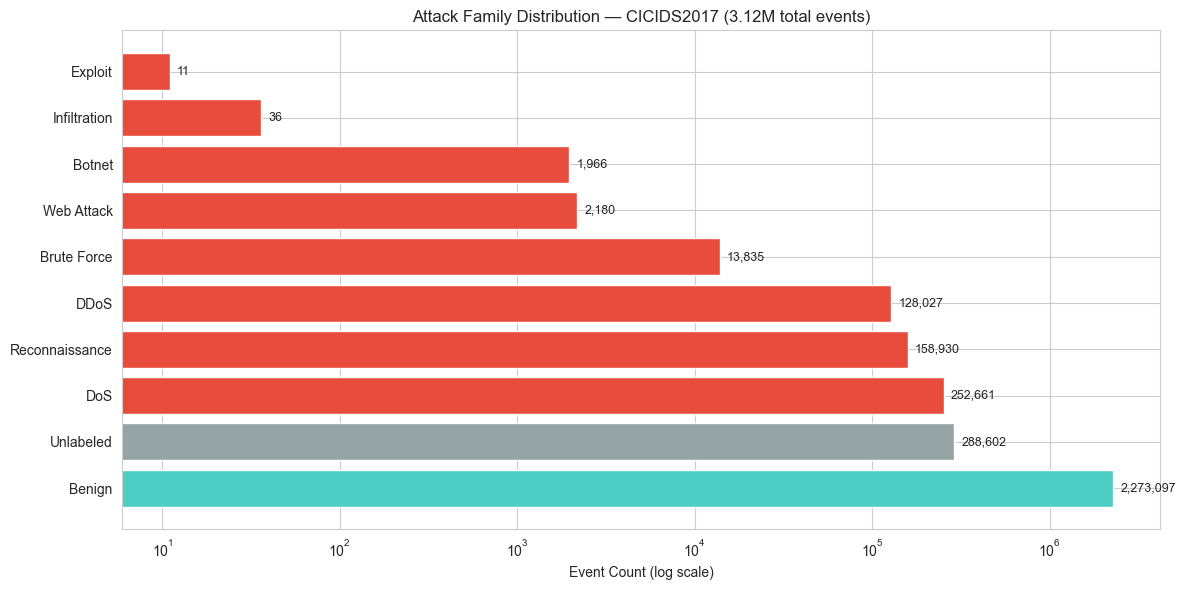

✅ Saved: 01_attack_family_distribution.png


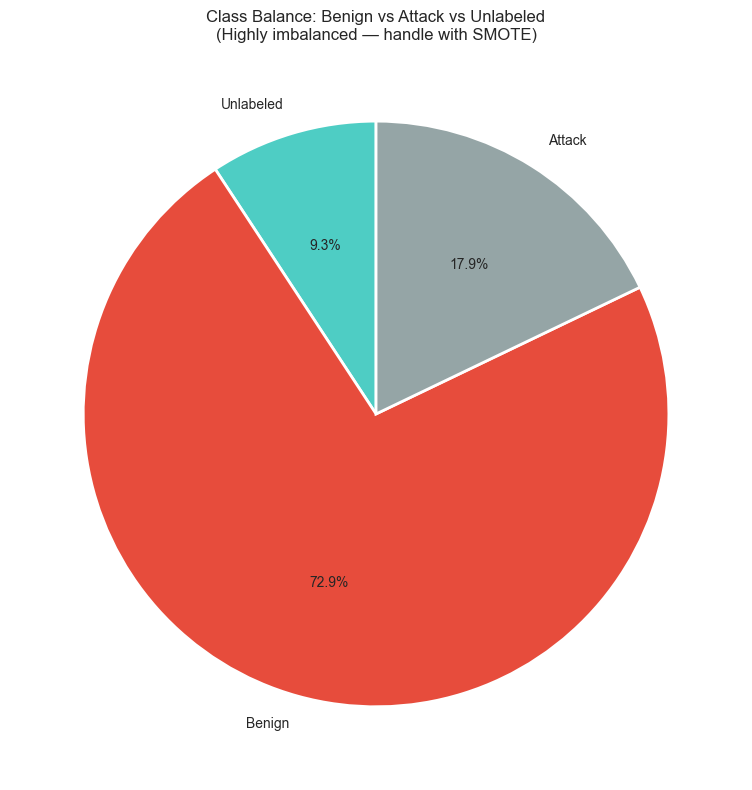

✅ Saved: 02_class_balance.png


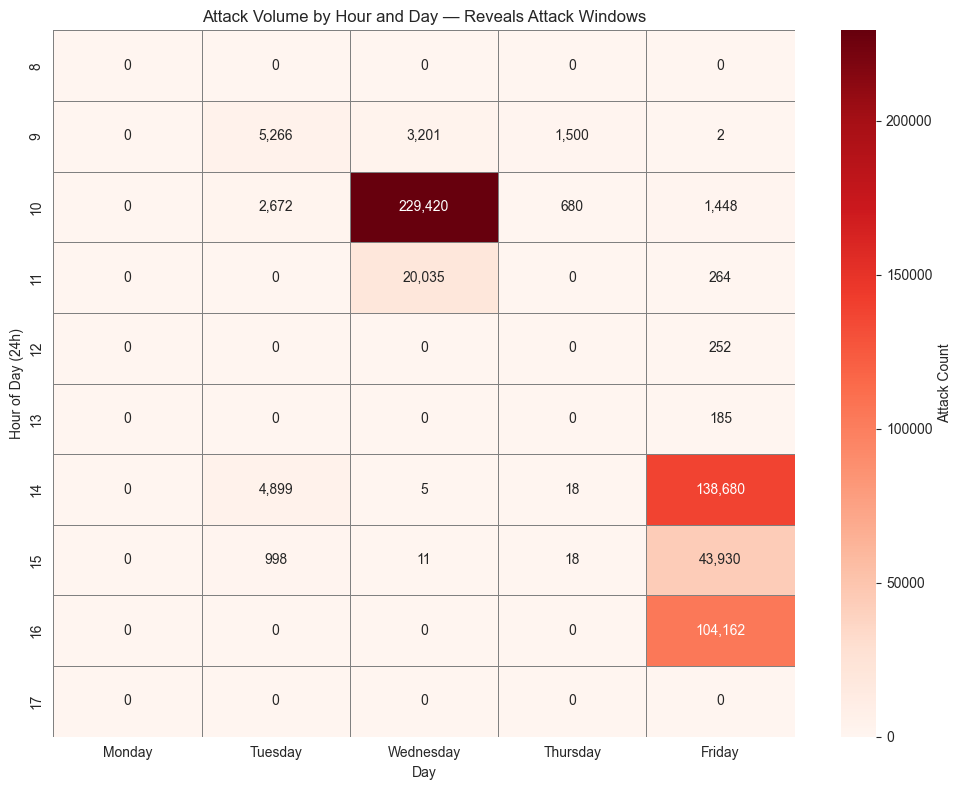

✅ Saved: 03_hourly_attack_heatmap.png


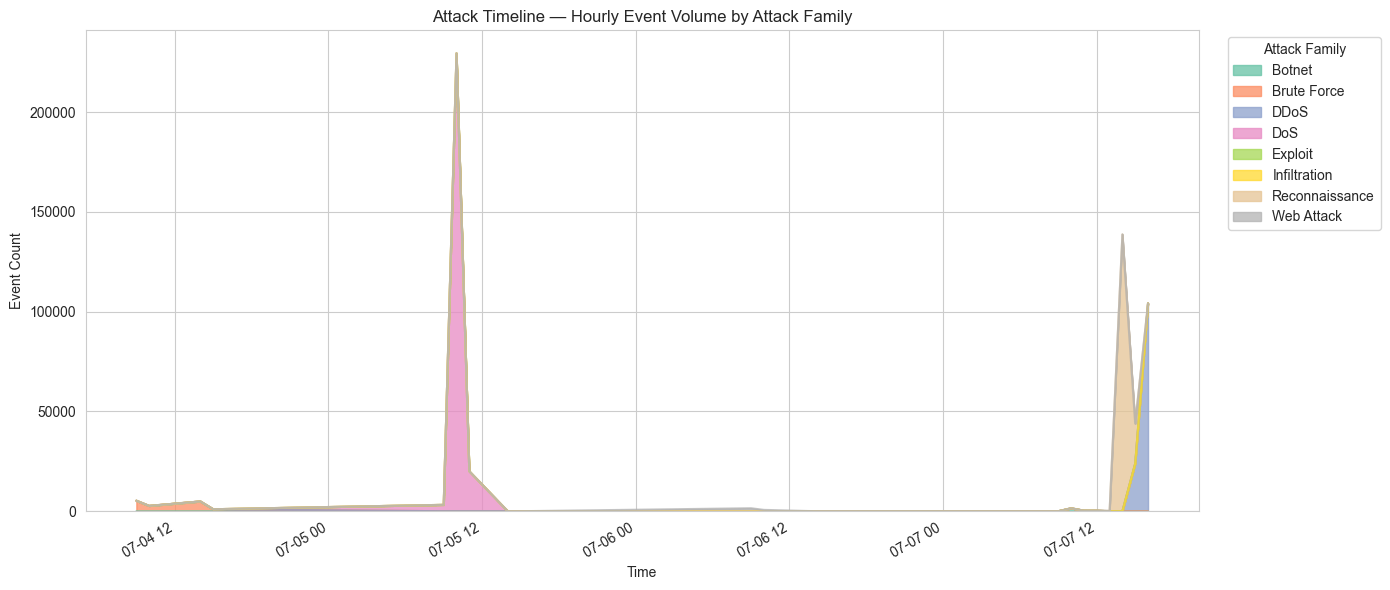

✅ Saved: 04_attack_timeline.png


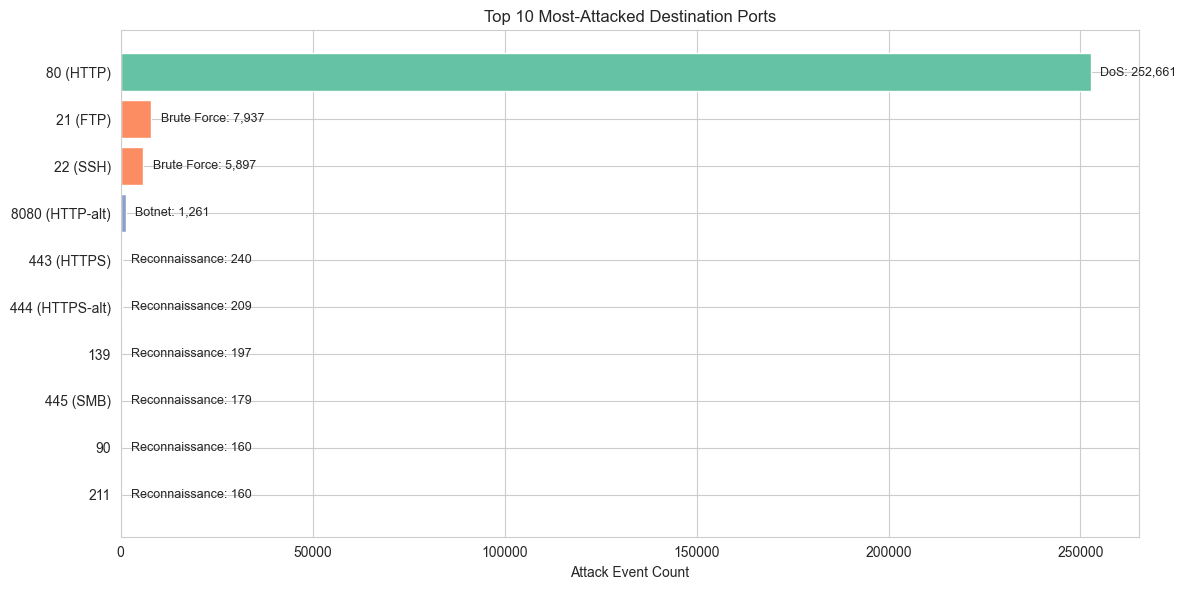

✅ Saved: 05_top_attacked_ports.png

🎉 All 5 figures saved to C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\figures


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import duckdb
from pathlib import Path

# Set up output directory
FIGURES_DIR = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reconnect to DuckDB for full dataset
DUCKDB_PATH = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\interim\cicids_eda.duckdb")
con = duckdb.connect(str(DUCKDB_PATH))

# Set common style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

# ============================================================
# Figure 1: Attack Family Distribution (log scale)
# ============================================================
attack_counts = con.execute("""
    SELECT attack_family, COUNT(*) AS cnt
    FROM stg_cicids_final
    GROUP BY attack_family
    ORDER BY cnt DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#4ecdc4' if f == 'Benign' else '#95a5a6' if f == 'Unlabeled' else '#e74c3c' 
          for f in attack_counts['attack_family']]
bars = ax.barh(attack_counts['attack_family'], attack_counts['cnt'], color=colors)
ax.set_xscale('log')
ax.set_xlabel('Event Count (log scale)')
ax.set_title('Attack Family Distribution — CICIDS2017 (3.12M total events)')
for bar, cnt in zip(bars, attack_counts['cnt']):
    ax.text(cnt * 1.1, bar.get_y() + bar.get_height()/2, f'{cnt:,}', 
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_attack_family_distribution.png")
plt.show()
print(f"✅ Saved: 01_attack_family_distribution.png")

# ============================================================
# Figure 2: Class Balance Pie (Benign vs Attack vs Unlabeled)
# ============================================================
class_dist = con.execute("""
    SELECT 
        CASE 
            WHEN is_attack = 0 THEN 'Benign'
            WHEN is_attack = 1 THEN 'Attack'
            ELSE 'Unlabeled'
        END AS class,
        COUNT(*) AS cnt
    FROM stg_cicids_final
    GROUP BY is_attack
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(class_dist['cnt'], labels=class_dist['class'], 
       autopct='%1.1f%%', startangle=90,
       colors=['#4ecdc4', '#e74c3c', '#95a5a6'],
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Class Balance: Benign vs Attack vs Unlabeled\n(Highly imbalanced — handle with SMOTE)', 
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_class_balance.png")
plt.show()
print(f"✅ Saved: 02_class_balance.png")

# ============================================================
# Figure 3: Hourly Attack Heatmap by Day
# ============================================================
hourly = con.execute("""
    SELECT 
        source_day,
        EXTRACT(HOUR FROM event_time) AS hour,
        SUM(CASE WHEN is_attack = 1 THEN 1 ELSE 0 END) AS attacks
    FROM stg_cicids_final
    WHERE event_time IS NOT NULL
    GROUP BY source_day, hour
""").fetchdf()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
pivot = hourly.pivot(index='hour', columns='source_day', values='attacks').fillna(0)
pivot = pivot[day_order]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Reds', 
            cbar_kws={'label': 'Attack Count'}, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('Attack Volume by Hour and Day — Reveals Attack Windows')
ax.set_xlabel('Day')
ax.set_ylabel('Hour of Day (24h)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_hourly_attack_heatmap.png")
plt.show()
print(f"✅ Saved: 03_hourly_attack_heatmap.png")

# ============================================================
# Figure 4: Attack Timeline (Stacked Area)
# ============================================================
timeline = con.execute("""
    SELECT 
        DATE_TRUNC('hour', event_time) AS hour_bucket,
        attack_family,
        COUNT(*) AS events
    FROM stg_cicids_final
    WHERE event_time IS NOT NULL 
      AND attack_family NOT IN ('Benign', 'Unlabeled')
    GROUP BY hour_bucket, attack_family
    ORDER BY hour_bucket
""").fetchdf()

pivot_t = timeline.pivot(index='hour_bucket', columns='attack_family', values='events').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_t.plot.area(ax=ax, alpha=0.75, colormap='Set2')
ax.set_title('Attack Timeline — Hourly Event Volume by Attack Family')
ax.set_xlabel('Time')
ax.set_ylabel('Event Count')
ax.legend(title='Attack Family', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_attack_timeline.png")
plt.show()
print(f"✅ Saved: 04_attack_timeline.png")

# ============================================================
# Figure 5: Top Attacked Ports
# ============================================================
ports = con.execute("""
    SELECT 
        "Destination Port" AS port,
        attack_family,
        COUNT(*) AS cnt
    FROM stg_cicids_final
    WHERE is_attack = 1
      AND "Destination Port" IS NOT NULL
    GROUP BY "Destination Port", attack_family
    QUALIFY ROW_NUMBER() OVER (PARTITION BY "Destination Port" ORDER BY COUNT(*) DESC) = 1
    ORDER BY cnt DESC
    LIMIT 10
""").fetchdf()

# Map known ports to friendly names
port_names = {80: '80 (HTTP)', 443: '443 (HTTPS)', 22: '22 (SSH)', 21: '21 (FTP)',
              53: '53 (DNS)', 8080: '8080 (HTTP-alt)', 444: '444 (HTTPS-alt)',
              25: '25 (SMTP)', 445: '445 (SMB)', 3389: '3389 (RDP)'}
ports['port_label'] = ports['port'].apply(lambda p: port_names.get(p, f'{p}'))

fig, ax = plt.subplots(figsize=(12, 6))
colors_attack = sns.color_palette("Set2", n_colors=ports['attack_family'].nunique())
family_color_map = dict(zip(ports['attack_family'].unique(), colors_attack))
bar_colors = [family_color_map[f] for f in ports['attack_family']]

bars = ax.barh(ports['port_label'], ports['cnt'], color=bar_colors)
ax.set_xlabel('Attack Event Count')
ax.set_title('Top 10 Most-Attacked Destination Ports')
ax.invert_yaxis()

# Annotate each bar with attack family
for bar, family, cnt in zip(bars, ports['attack_family'], ports['cnt']):
    ax.text(cnt + max(ports['cnt'])*0.01, bar.get_y() + bar.get_height()/2,
            f'{family}: {cnt:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_top_attacked_ports.png")
plt.show()
print(f"✅ Saved: 05_top_attacked_ports.png")

print(f"\n🎉 All 5 figures saved to {FIGURES_DIR}")

In [11]:
import duckdb
from pathlib import Path
from datetime import datetime

DUCKDB_PATH = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\data\interim\cicids_eda.duckdb")
DOCS_DIR = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs")
DOCS_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DUCKDB_PATH))

# Pull live stats
total_rows = con.execute("SELECT COUNT(*) FROM stg_cicids_final").fetchone()[0]
total_cols = con.execute("SELECT COUNT(*) FROM (DESCRIBE stg_cicids_final)").fetchone()[0]

label_dist = con.execute("""
    SELECT label_clean, attack_family, COUNT(*) AS cnt
    FROM stg_cicids_final
    GROUP BY label_clean, attack_family
    ORDER BY cnt DESC
""").fetchdf()

family_dist = con.execute("""
    SELECT attack_family, COUNT(*) AS cnt,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM stg_cicids_final), 2) AS pct
    FROM stg_cicids_final
    GROUP BY attack_family
    ORDER BY cnt DESC
""").fetchdf()

day_dist = con.execute("""
    SELECT source_day, COUNT(*) AS cnt,
           MIN(event_time) AS earliest,
           MAX(event_time) AS latest
    FROM stg_cicids_final
    GROUP BY source_day
    ORDER BY MIN(event_time)
""").fetchdf()

attack_windows = con.execute("""
    SELECT label_clean, source_day,
           MIN(event_time) AS first_seen,
           MAX(event_time) AS last_seen,
           COUNT(*) AS events
    FROM stg_cicids_final
    WHERE attack_family NOT IN ('Benign', 'Unlabeled')
    GROUP BY label_clean, source_day
    ORDER BY source_day, MIN(event_time)
""").fetchdf()

schema_df = con.execute("DESCRIBE stg_cicids_final").fetchdf()

# Build markdown
md = []
md.append("# CICIDS2017 Data Dictionary")
md.append("")
md.append(f"_Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}_")
md.append("")
md.append("## 1. Source")
md.append("")
md.append("- **Dataset:** CICIDS2017 (Canadian Institute for Cybersecurity)")
md.append("- **Authors:** Sharafaldin, Lashkari, Ghorbani (2018)")
md.append("- **Paper:** \"Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization\"")
md.append("- **Distribution:** GeneratedLabelledFlows.zip (preserves IPs, ports, timestamps)")
md.append("- **URL:** https://www.unb.ca/cic/datasets/ids-2017.html")
md.append("")
md.append("## 2. Volume")
md.append("")
md.append(f"- **Total events:** {total_rows:,}")
md.append(f"- **Total columns:** {total_cols}")
md.append("- **Files:** 8 CSVs covering Mon–Fri, 3–7 July 2017")
md.append("- **Storage:** ~1 GB raw CSV → ~150-250 MB parquet (cleaned)")
md.append("")
md.append("### Per-Day Breakdown")
md.append("")
md.append("| Day | Rows | Earliest | Latest |")
md.append("|---|---|---|---|")
for _, r in day_dist.iterrows():
    md.append(f"| {r['source_day']} | {r['cnt']:,} | {r['earliest']} | {r['latest']} |")
md.append("")

md.append("## 3. Attack Categories")
md.append("")
md.append("### Attack Family Distribution (high-level grouping)")
md.append("")
md.append("| Attack Family | Event Count | Percentage |")
md.append("|---|---|---|")
for _, r in family_dist.iterrows():
    md.append(f"| {r['attack_family']} | {r['cnt']:,} | {r['pct']}% |")
md.append("")

md.append("### Detailed Label Distribution")
md.append("")
md.append("| Label | Attack Family | Event Count |")
md.append("|---|---|---|")
for _, r in label_dist.iterrows():
    md.append(f"| {r['label_clean']} | {r['attack_family']} | {r['cnt']:,} |")
md.append("")

md.append("## 4. Documented Attack Windows")
md.append("")
md.append("| Day | Attack | First Seen | Last Seen | Events |")
md.append("|---|---|---|---|---|")
for _, r in attack_windows.iterrows():
    md.append(f"| {r['source_day']} | {r['label_clean']} | {r['first_seen']} | {r['last_seen']} | {r['events']:,} |")
md.append("")

md.append("## 5. Schema (Cleaned `stg_cicids_final`)")
md.append("")
md.append("| Column | Type |")
md.append("|---|---|")
for _, r in schema_df.iterrows():
    md.append(f"| `{r['column_name']}` | {r['column_type']} |")
md.append("")

md.append("## 6. Derived Columns (Added During Cleaning)")
md.append("")
md.append("| Column | Type | Purpose |")
md.append("|---|---|---|")
md.append("| `label_clean` | VARCHAR | Normalized label (em-dash artifact `\\x96` replaced with `-`, NULLs marked 'Unlabeled') |")
md.append("| `attack_family` | VARCHAR | High-level grouping (Benign/DoS/DDoS/Reconnaissance/Brute Force/Web Attack/Botnet/Infiltration/Exploit/Unlabeled) |")
md.append("| `is_attack` | INTEGER | Binary ML target (0=Benign, 1=Attack, NULL=Unlabeled — excluded from supervised training) |")
md.append("| `source_day` | VARCHAR | Day of week (added during ETL for time analysis) |")
md.append("| `event_time` | TIMESTAMP | Parsed timestamp with AM/PM business-hour inference |")
md.append("")

md.append("## 7. Data Quality Issues Encountered & Resolved")
md.append("")
md.append("This dataset has well-known issues. Below are the ones encountered and how they were handled:")
md.append("")
md.append("### Issue 1: Inconsistent Timestamp Formats")
md.append("- **Problem:** Monday uses `dd/mm/YYYY HH:MM:SS` (zero-padded with seconds); other days use `d/m/YYYY H:MM` (no padding, no seconds)")
md.append("- **Resolution:** Branched parser logic by `source_day`")
md.append("")
md.append("### Issue 2: 12-Hour Format Without AM/PM Markers")
md.append("- **Problem:** Times appear as 1:00, 2:00, etc. with no AM/PM. Could mean morning or afternoon.")
md.append("- **Resolution:** Used CICIDS2017 documentation (8 AM – 5 PM business hours) to infer: hours 1-5 → PM, hours 8-12 → AM")
md.append("- **Validation:** Parsed attack times match documented attack windows exactly (e.g. Heartbleed at 15:12-15:32 matches docs)")
md.append("")
md.append("### Issue 3: Inf/NaN Values in Numeric Columns")
md.append("- **Problem:** `Flow Bytes/s` and `Flow Packets/s` contain `Infinity`, `inf`, and `NaN` strings (~5,700 rows)")
md.append("- **Resolution:** Cast via `CASE WHEN ILIKE '%inf%' OR '%nan%' THEN NULL ELSE TRY_CAST(...) END`")
md.append("")
md.append("### Issue 4: Encoding Artifact in Web Attack Labels")
md.append("- **Problem:** Latin-1 character `\\x96` (em-dash) appears in labels like `Web Attack \\x96 XSS`")
md.append("- **Resolution:** Loaded WebAttacks file via pandas with `encoding='latin-1'`; normalized via REGEXP_REPLACE")
md.append("")
md.append("### Issue 5: Broken CSV Parsing in WebAttacks File")
md.append("- **Problem:** DuckDB's `read_csv` with `ignore_errors=true` silently produced 288,602 NULL-filled phantom rows")
md.append("- **Resolution:** Used pandas (which handles the file cleanly), then pushed to DuckDB")
md.append("")
md.append("### Issue 6: Genuine Unlabeled Rows (Known Dataset Flaw)")
md.append("- **Problem:** 288,602 Thursday-WebAttacks rows have empty Label fields — a documented CICIDS2017 quality issue from the original CICFlowMeter generation")
md.append("- **Resolution:** Marked as 'Unlabeled' (`is_attack = NULL`); excluded from supervised ML training, included in volumetric BI dashboards for transparency")
md.append("")
md.append("### Issue 7: Severe Class Imbalance")
md.append("- **Problem:** ~80:20 Benign:Attack ratio; some attacks (Infiltration: 36, Heartbleed: 11) have <50 samples")
md.append("- **Resolution:** Will use SMOTE oversampling + class-weighted losses in Week 4 ML phase")
md.append("")
md.append("### Issue 8: Duplicate Column Name (`Fwd Header Length` & `Fwd Header Length_1`)")
md.append("- **Problem:** Original dataset accidentally duplicated this column")
md.append("- **Resolution:** Dropped `Fwd Header Length_1` during column selection")
md.append("")

md.append("## 8. Network Topology (Inferred from Data)")
md.append("")
md.append("### Internal Network (192.168.10.0/24)")
md.append("")
md.append("| IP | Role | Evidence |")
md.append("|---|---|---|")
md.append("| `192.168.10.50` | **Primary Web Server (Victim)** | Receives 555K attacks: DoS, DDoS, Recon, Brute Force, Web Attack |")
md.append("| `192.168.10.51` | Secondary Server | 11 Heartbleed attacks |")
md.append("| `192.168.10.5/8/9/14/15` | Workstations (Bot-compromised) | All show Botnet in source and destination |")
md.append("| `192.168.10.8` | Insider Threat Origin | Source of 36 Infiltration events |")
md.append("| `192.168.10.3` | Internal Service (DNS/AD) | Highest volume, no attacks |")
md.append("| `192.168.10.1` | Gateway/Router | High volume, no attacks |")
md.append("")
md.append("### External Actors")
md.append("")
md.append("| IP | Role |")
md.append("|---|---|")
md.append("| `205.174.165.73` | **The Documented External Attacker** — DDoS source, Heartbleed exploitation |")
md.append("")

md.append("## 9. Geographic Mapping Strategy")
md.append("")
md.append("- **External IPs identified:** 19,035 (mostly benign destinations from internal browsing)")
md.append("- **External attackers:** 1 (`205.174.165.73`)")
md.append("- **Approach:** \"Network Communication Footprint\" map — shows where internal hosts reach out, with the single attacker IP highlighted")
md.append("- **Internal network visualization:** separate dashboard component (host-to-host attack graph)")
md.append("- **Enrichment plan (Week 3):** MaxMind GeoLite2-City lookup for all 19,035 external IPs; AbuseIPDB enrichment for top-N suspicious IPs (rate-limit aware)")
md.append("- **External IP master list:** `data/interim/external_ips_master.csv`")
md.append("")

md.append("## 10. Files Generated in Week 1")
md.append("")
md.append("| Artifact | Path |")
md.append("|---|---|")
md.append("| Cleaned dataset (Parquet) | `data/interim/cicids_clean.parquet` |")
md.append("| EDA staging database | `data/interim/cicids_eda.duckdb` |")
md.append("| External IPs to geocode | `data/interim/external_ips_to_geocode.csv` |")
md.append("| External attacker profile | `data/interim/external_attackers_profile.csv` |")
md.append("| Master external IP list | `data/interim/external_ips_master.csv` |")
md.append("| PostgreSQL stratified sample | `staging.stg_cicids_sample` (12,047 rows) |")
md.append("| EDA notebook | `notebooks/01_cicids2017_eda.ipynb` |")
md.append("| EDA visualizations | `docs/figures/01_*.png` through `05_*.png` |")
md.append("")

md.append("## 11. CICIDS2017 Source Files Used")
md.append("")
md.append("| File | Day | Primary Attacks |")
md.append("|---|---|---|")
md.append("| `Monday-WorkingHours.pcap_ISCX.csv` | Mon | None (benign baseline) |")
md.append("| `Tuesday-WorkingHours.pcap_ISCX.csv` | Tue | FTP-Patator, SSH-Patator |")
md.append("| `Wednesday-workingHours.pcap_ISCX.csv` | Wed | DoS variants, Heartbleed |")
md.append("| `Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv` | Thu AM | Web attacks (XSS, SQLi, BF) — **had encoding issues** |")
md.append("| `Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv` | Thu PM | Infiltration |")
md.append("| `Friday-WorkingHours-Morning.pcap_ISCX.csv` | Fri AM | Botnet |")
md.append("| `Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv` | Fri PM | PortScan |")
md.append("| `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv` | Fri PM | DDoS |")
md.append("")

md_content = "\n".join(md)
output_file = DOCS_DIR / "data_dictionary_cicids2017.md"
output_file.write_text(md_content, encoding='utf-8')

print(f"✅ Data dictionary saved: {output_file}")
print(f"   Size: {output_file.stat().st_size / 1024:.1f} KB")
print(f"   Lines: {len(md)}")

✅ Data dictionary saved: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\data_dictionary_cicids2017.md
   Size: 12.0 KB
   Lines: 280
